# Hệ thống gợi ý việc làm (Job Recommendation System)

# Phần 1: Giới thiệu chung

## Phạm vi bài toán
Trong notebook này, chúng ta xây dựng hệ thống gợi ý Job Post cho Candidate dựa trên:
- Nội dung hồ sơ ứng viên (summary, education, expect_salary, skills)
- Nội dung mô tả công việc (description, salary, salary_type, industry, job_type, level, skills)

## Phương pháp
Sử dụng **Content-based Recommendation**:
- So sánh độ tương đồng giữa Candidate và Job Post
- Gợi ý Top-N công việc phù hợp nhất

## Các phần trong notebook:
- Load dữ liệu & EDA nền tảng
- Tiền xử lý dữ liệu (text + numeric + categorical)
- Xây dựng vector Candidate & Job
- Mô hình gợi ý (Similarity Model)
- Đánh giá mô hình (offline evaluation)
- Tổng kết & hướng cải tiến khi có thêm data


# Phần 2: LOAD DỮ LIỆU & EDA NỀN TẢNG


## 2.1. Import thư viện cần thiết

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import hstack, csr_matrix
import warnings
warnings.filterwarnings('ignore')

# Cấu hình hiển thị
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
plt.rcParams['font.size'] = 12
plt.rcParams['figure.figsize'] = (12, 6)


## 2.2. Load dữ liệu từ CSV

In [2]:
# Load các bảng dữ liệu chính
candidates = pd.read_csv("../data/csv_data/candidates.csv")
users = pd.read_csv("../data/csv_data/users.csv")
candidates_skills = pd.read_csv("../data/csv_data/candidates_skills.csv")
skills = pd.read_csv("../data/csv_data/skills.csv")

job_posts = pd.read_csv("../data/csv_data/job_posts.csv")
job_posts_skills = pd.read_csv("../data/csv_data/job_posts_skills.csv")
industries = pd.read_csv("../data/csv_data/industries.csv")
levels = pd.read_csv("../data/csv_data/levels.csv")
job_types = pd.read_csv("../data/csv_data/job_types.csv")

print("=== THÔNG TIN CÁC BẢNG DỮ LIỆU ===")
print(f"Candidates: {len(candidates)} records")
print(f"Users: {len(users)} records")
print(f"Candidates Skills: {len(candidates_skills)} records")
print(f"Skills: {len(skills)} records")
print(f"Job Posts: {len(job_posts)} records")
print(f"Job Posts Skills: {len(job_posts_skills)} records")
print(f"Industries: {len(industries)} records")
print(f"Levels: {len(levels)} records")
print(f"Job Types: {len(job_types)} records")


=== THÔNG TIN CÁC BẢNG DỮ LIỆU ===
Candidates: 100 records
Users: 201 records
Candidates Skills: 2222 records
Skills: 62 records
Job Posts: 327 records
Job Posts Skills: 829 records
Industries: 89 records
Levels: 43 records
Job Types: 8 records


## 2.3. Khám phá dữ liệu Candidate

In [3]:
print("=== CANDIDATES TABLE ===")
print(candidates.info())
print("\n--- Sample data ---")
candidates.head()


=== CANDIDATES TABLE ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   dob            49 non-null     object 
 1   education      59 non-null     object 
 2   expect_salary  55 non-null     float64
 3   gender         54 non-null     float64
 4   id             100 non-null    object 
dtypes: float64(2), object(3)
memory usage: 4.0+ KB
None

--- Sample data ---


,dob,education,expect_salary,gender,id
0,1998-02-10,,39000000.0,1.0,00fc28fb-86af-440c-ae99-6b98ad7debdb
1,1992-07-30,Thạc sĩ CNTT,35000000.0,1.0,04149279-92bf-422b-a0df-798f3611a1c5
2,1995-12-01,Cử nhân Quản trị kinh doanh,15000000.0,0.0,0746450e-92c6-4c1a-8fc7-ea2ee9cc6d42
3,1999-10-05,Đại học Khoa học Tự nhiên,18000000.0,1.0,0944b2dc-7e8f-4e92-9263-596d6b978946
4,1994-07-26,Cử nhân Công nghệ thông tin,0.0,1.0,0dffbd1a-2d8a-431f-ae68-fd314fbe46dc


In [4]:
print("=== USERS TABLE (chứa summary) ===")
print(users.info())
print("\n--- Sample data ---")
users[['id', 'full_name', 'summary']].head()


=== USERS TABLE (chứa summary) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           201 non-null    object 
 1   created_at   201 non-null    object 
 2   email        200 non-null    object 
 3   full_name    194 non-null    object 
 4   image_url    201 non-null    object 
 5   password     201 non-null    object 
 6   phone        107 non-null    object 
 7   summary      126 non-null    object 
 8   updated_at   201 non-null    object 
 9   user_status  201 non-null    object 
 10  username     201 non-null    object 
 11  region_id    0 non-null      float64
dtypes: float64(1), object(11)
memory usage: 19.0+ KB
None

--- Sample data ---


,id,full_name,summary
0,00fc28fb-86af-440c-ae99-6b98ad7debdb,Lê Quốc Việt,Frontend Developer với ReactJS
1,04149279-92bf-422b-a0df-798f3611a1c5,Lê Minh Hoàng,Frontend Developer
2,04991cc9-2d5f-4a33-846b-cb328c9adfde,Đặng Minh Lan,Frontend developer ReactJS.
3,05a1273e-0dfb-4f97-ba5f-400ffb39244f,Global Soft,Công ty phần mềm quốc tế
4,06c39b46-dc0c-40ed-af9c-1fd90e0e1841,Võ Phúc,Tester manual và automation.


In [5]:
# Merge candidates với users để lấy summary
candidates_full = candidates.merge(users[['id', 'full_name', 'summary']], on='id', how='left')
print("=== CANDIDATES FULL ===")
print(f"Shape: {candidates_full.shape}")
candidates_full.head()


=== CANDIDATES FULL ===
Shape: (100, 7)


,dob,education,expect_salary,gender,id,full_name,summary
0,1998-02-10,,39000000.0,1.0,00fc28fb-86af-440c-ae99-6b98ad7debdb,Lê Quốc Việt,Frontend Developer với ReactJS
1,1992-07-30,Thạc sĩ CNTT,35000000.0,1.0,04149279-92bf-422b-a0df-798f3611a1c5,Lê Minh Hoàng,Frontend Developer
2,1995-12-01,Cử nhân Quản trị kinh doanh,15000000.0,0.0,0746450e-92c6-4c1a-8fc7-ea2ee9cc6d42,Nguyễn Hùng,Nhân sự tuyển dụng IT.
3,1999-10-05,Đại học Khoa học Tự nhiên,18000000.0,1.0,0944b2dc-7e8f-4e92-9263-596d6b978946,Lê Thanh An,"Kỹ sư phần mềm, làm việc với hệ thống lớn."
4,1994-07-26,Cử nhân Công nghệ thông tin,0.0,1.0,0dffbd1a-2d8a-431f-ae68-fd314fbe46dc,NaN,Nhân sự tuyển dụng IT.


In [6]:
# Thống kê missing values cho candidates
print("=== MISSING VALUES - CANDIDATES ===")
missing_candidates = candidates_full.isnull().sum()
missing_percent = (missing_candidates / len(candidates_full) * 100).round(2)
pd.DataFrame({'Missing Count': missing_candidates, 'Missing %': missing_percent})


=== MISSING VALUES - CANDIDATES ===


,Missing Count,Missing %
dob,51,51.0
education,41,41.0
expect_salary,45,45.0
gender,46,46.0
id,0,0.0
full_name,3,3.0
summary,41,41.0


## 2.4. Khám phá dữ liệu Job Posts

In [7]:
print("=== JOB POSTS TABLE ===")
print(job_posts.info())
print("\n--- Sample data ---")
job_posts.head()


=== JOB POSTS TABLE ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 327 entries, 0 to 326
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            327 non-null    object 
 1   created_at    327 non-null    object 
 2   description   311 non-null    object 
 3   ended_time    185 non-null    object 
 4   quantity      327 non-null    int64  
 5   salary        298 non-null    float64
 6   salary_type   267 non-null    object 
 7   status        250 non-null    object 
 8   title         288 non-null    object 
 9   updated_at    327 non-null    object 
 10  industry_id   327 non-null    int64  
 11  job_type_id   327 non-null    int64  
 12  level_id      327 non-null    int64  
 13  recruiter_id  327 non-null    object 
 14  region_id     327 non-null    int64  
dtypes: float64(1), int64(5), object(9)
memory usage: 38.4+ KB
None

--- Sample data ---


,id,created_at,description,ended_time,quantity,salary,salary_type,status,title,updated_at,industry_id,job_type_id,level_id,recruiter_id,region_id
0,002d35b1-1ff1-45f8-b0ef-7897d2584554,2025-06-25 22:14:31.124041,Hiểu biết về Machine Learning,2024-08-24 00:00:00.000000,-1,25000000.0,PROJECT,PRIVATE,Lập trình viên Python,2025-11-22 22:14:31.124060,62,5,38,78f2025f-0195-47ef-9d50-f8ffc934395b,12
1,007cd194-f5de-4af1-b299-ffe7dc314e76,2025-11-15 21:28:52.735120,Yêu cầu kinh nghiệm 2 năm,2024-03-21 00:00:00.000000,2,10000000.0,MONTHS,NaN,Lập trình viên Python,2025-11-27 21:28:52.735124,89,7,28,4f1dd8f2-518e-4e07-9c4d-0848791327a4,11
2,0138730f-d1f2-49c4-a72b-582f8a75ba48,2025-08-17 22:14:31.139596,Có thể làm việc nhóm tốt,NaN,3,18000000.0,NaN,PUBLIC,Kỹ sư dữ liệu,2025-11-27 22:14:31.139604,84,6,25,56a915b2-6add-4e42-b31d-81fda3bf7485,82
3,0181d9a3-aa61-490e-b8f7-aa219e80e74a,2025-08-16 22:14:31.190260,undefined,NaN,1,18000000.0,NEGOTIATION,NaN,Kỹ sư AI,2025-11-25 22:14:31.190271,28,7,15,ea651dc9-312a-49a3-8c6c-3b9be7615a1a,91
4,03d649a5-a55b-4162-9064-4e54c6d43a11,2025-12-08 21:28:52.734655,Hiểu biết về Machine Learning,2025-03-22 00:00:00.000000,3,20000000.0,NaN,PRIVATE,Kỹ sư dữ liệu,2025-12-06 21:28:52.734660,4,2,8,41420dc1-d801-4065-bec6-7dc885cb2b76,80


In [8]:
# Merge job_posts với industries, levels, job_types
job_posts_full = job_posts.merge(industries[['id', 'name']], left_on='industry_id', right_on='id', how='left', suffixes=('', '_industry'))
job_posts_full = job_posts_full.rename(columns={'name': 'industry_name'})
job_posts_full = job_posts_full.drop(columns=['id_industry'], errors='ignore')

job_posts_full = job_posts_full.merge(levels[['id', 'name']], left_on='level_id', right_on='id', how='left', suffixes=('', '_level'))
job_posts_full = job_posts_full.rename(columns={'name': 'level_name'})
job_posts_full = job_posts_full.drop(columns=['id_level'], errors='ignore')

job_posts_full = job_posts_full.merge(job_types[['id', 'name']], left_on='job_type_id', right_on='id', how='left', suffixes=('', '_job_type'))
job_posts_full = job_posts_full.rename(columns={'name': 'job_type_name'})
job_posts_full = job_posts_full.drop(columns=['id_job_type'], errors='ignore')

print("=== JOB POSTS FULL ===")
print(f"Shape: {job_posts_full.shape}")
job_posts_full[['id', 'title', 'description', 'salary', 'salary_type', 'industry_name', 'level_name', 'job_type_name']].head()


=== JOB POSTS FULL ===
Shape: (327, 18)


,id,title,description,salary,salary_type,industry_name,level_name,job_type_name
0,002d35b1-1ff1-45f8-b0ef-7897d2584554,Lập trình viên Python,Hiểu biết về Machine Learning,25000000.0,PROJECT,Sư phạm Lịch sử,Nhà văn / Biên tập viên (Writer),Hợp đồng ngắn hạn
1,007cd194-f5de-4af1-b299-ffe7dc314e76,Lập trình viên Python,Yêu cầu kinh nghiệm 2 năm,10000000.0,MONTHS,Kỹ thuật Robot,Hiệu trưởng / Giám đốc trung tâm (Principal),Thời vụ
2,0138730f-d1f2-49c4-a72b-582f8a75ba48,Kỹ sư dữ liệu,Có thể làm việc nhóm tốt,18000000.0,NaN,Kỹ thuật điều khiển và tự động hóa,Giám đốc tài chính (CFO),Cộng tác viên
3,0181d9a3-aa61-490e-b8f7-aa219e80e74a,Kỹ sư AI,undefined,18000000.0,NEGOTIATION,Xây dựng cảng - công trình biển,Giám sát viên (Supervisor),Thời vụ
4,03d649a5-a55b-4162-9064-4e54c6d43a11,Kỹ sư dữ liệu,Hiểu biết về Machine Learning,20000000.0,NaN,An ninh mạng,Chuyên gia (Expert),Bán thời gian


In [9]:
# Thống kê missing values cho job_posts
print("=== MISSING VALUES - JOB POSTS ===")
missing_jobs = job_posts_full.isnull().sum()
missing_percent_jobs = (missing_jobs / len(job_posts_full) * 100).round(2)
pd.DataFrame({'Missing Count': missing_jobs, 'Missing %': missing_percent_jobs})


=== MISSING VALUES - JOB POSTS ===


,Missing Count,Missing %
id,0,0.00
created_at,0,0.00
description,16,4.89
ended_time,142,43.43
quantity,0,0.00
salary,29,8.87
salary_type,60,18.35
status,77,23.55
title,39,11.93
updated_at,0,0.00


## 2.5. Khám phá dữ liệu Skills

In [10]:
print("=== SKILLS TABLE ===")
skills.head(10)

=== SKILLS TABLE ===


,id,description,name
0,1,Xây dựng mô hình học máy.,Machine Learning
1,2,Thư viện frontend cho UI.,ReactJS
2,3,Framework backend từ Microsoft.,ASP.NET
3,4,Xử lý ảnh và thị giác máy tính.,Computer Vision
4,5,Quản lý lớp học hiệu quả.,Class Management
5,6,"Dùng trong backend, AI và automation.",Python
6,7,Quản lý container tối ưu.,Kubernetes
7,8,Sáng tạo trong giải pháp và ý tưởng.,Creativity
8,9,Phiên bản mở rộng của JavaScript.,TypeScript
9,10,Bảo mật ứng dụng và hệ thống.,Cyber Security


In [11]:
# Tạo mapping skills cho candidates
candidate_skills_grouped = candidates_skills.merge(skills[['id', 'name']], left_on='skills_id', right_on='id', how='left')
candidate_skills_agg = candidate_skills_grouped.groupby('candidate_id')['name'].apply(lambda x: ', '.join(x.dropna())).reset_index()
candidate_skills_agg.columns = ['candidate_id', 'skills_list']
print("=== CANDIDATE SKILLS AGGREGATED ===")
candidate_skills_agg.head()


=== CANDIDATE SKILLS AGGREGATED ===


,candidate_id,skills_list
0,00fc28fb-86af-440c-ae99-6b98ad7debdb,"Python, Cyber Security, MongoDB, Laravel, Flask, Angular, Teamwork, Django, iOS, Spring Boot, SE..."
1,04149279-92bf-422b-a0df-798f3611a1c5,"ASP.NET, Computer Vision, Python, Creativity, TypeScript, Flask, Digital Marketing, Teamwork, Me..."
2,0746450e-92c6-4c1a-8fc7-ea2ee9cc6d42,"ReactJS, Class Management, Creativity, Cyber Security, MySQL, Revit, Laravel, Flask, Angular, An..."
3,0944b2dc-7e8f-4e92-9263-596d6b978946,"Machine Learning, ReactJS, Class Management, Python, Creativity, Cyber Security, JavaScript, Mon..."
4,0dffbd1a-2d8a-431f-ae68-fd314fbe46dc,"Python, Creativity, Revit, MongoDB, Laravel, Digital Marketing, Android, Audit, SQL, Time Manage..."


In [12]:
# Tạo mapping skills cho job_posts
job_skills_grouped = job_posts_skills.merge(skills[['id', 'name']], left_on='skills_id', right_on='id', how='left')
job_skills_agg = job_skills_grouped.groupby('job_post_id')['name'].apply(lambda x: ', '.join(x.dropna())).reset_index()
job_skills_agg.columns = ['job_post_id', 'skills_list']
print("=== JOB POSTS SKILLS AGGREGATED ===")
job_skills_agg.head()


=== JOB POSTS SKILLS AGGREGATED ===


,job_post_id,skills_list
0,002d35b1-1ff1-45f8-b0ef-7897d2584554,"Teamwork, NodeJS, Business Analysis, Deep Learning"
1,0138730f-d1f2-49c4-a72b-582f8a75ba48,"Machine Learning, Docker, Spring Boot, Azure Cloud, VueJS"
2,0181d9a3-aa61-490e-b8f7-aa219e80e74a,"VueJS, Accounting"
3,04621b89-3368-4224-b0f6-01b37e71ec51,"Revit, AutoCAD, Audit, Time Management, Networking"
4,053b4ace-3b98-48de-9baf-4339e5980fd4,"Revit, Customer Service"


## 2.6. EDA - Exploratory Data Analysis

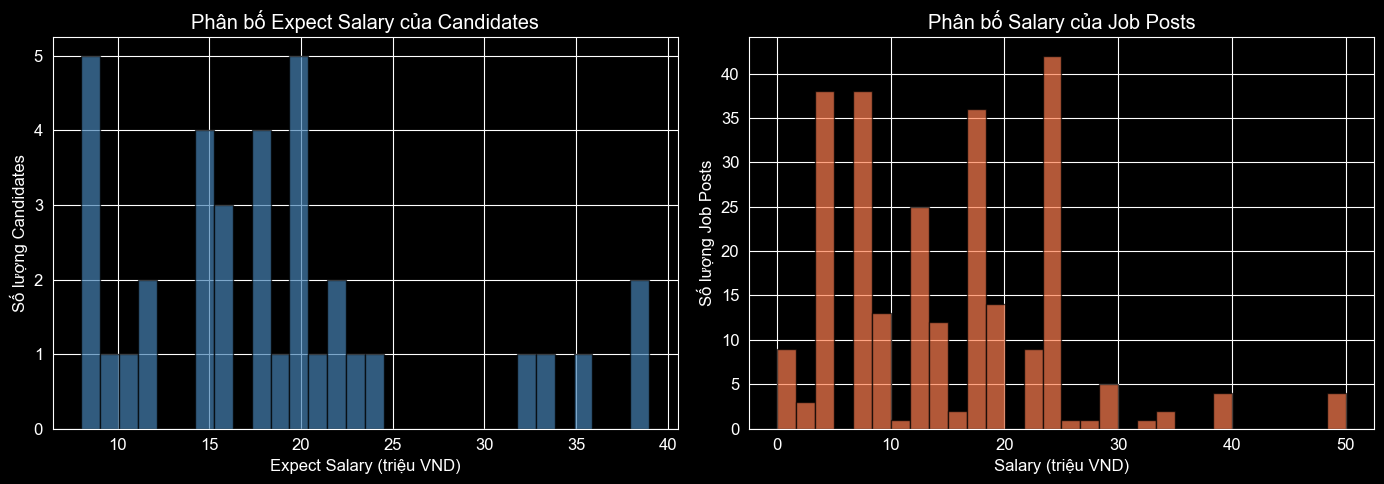

In [13]:
# Phân bố salary của candidates
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Candidate expect salary
valid_salary_candidates = candidates_full[candidates_full['expect_salary'] > 0]['expect_salary']
axes[0].hist(valid_salary_candidates / 1000000, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Expect Salary (triệu VND)')
axes[0].set_ylabel('Số lượng Candidates')
axes[0].set_title('Phân bố Expect Salary của Candidates')

# Job posts salary
valid_salary_jobs = job_posts_full[job_posts_full['salary'] > 0]['salary']
axes[1].hist(valid_salary_jobs / 1000000, bins=30, edgecolor='black', alpha=0.7, color='coral')
axes[1].set_xlabel('Salary (triệu VND)')
axes[1].set_ylabel('Số lượng Job Posts')
axes[1].set_title('Phân bố Salary của Job Posts')

plt.tight_layout()
plt.show()


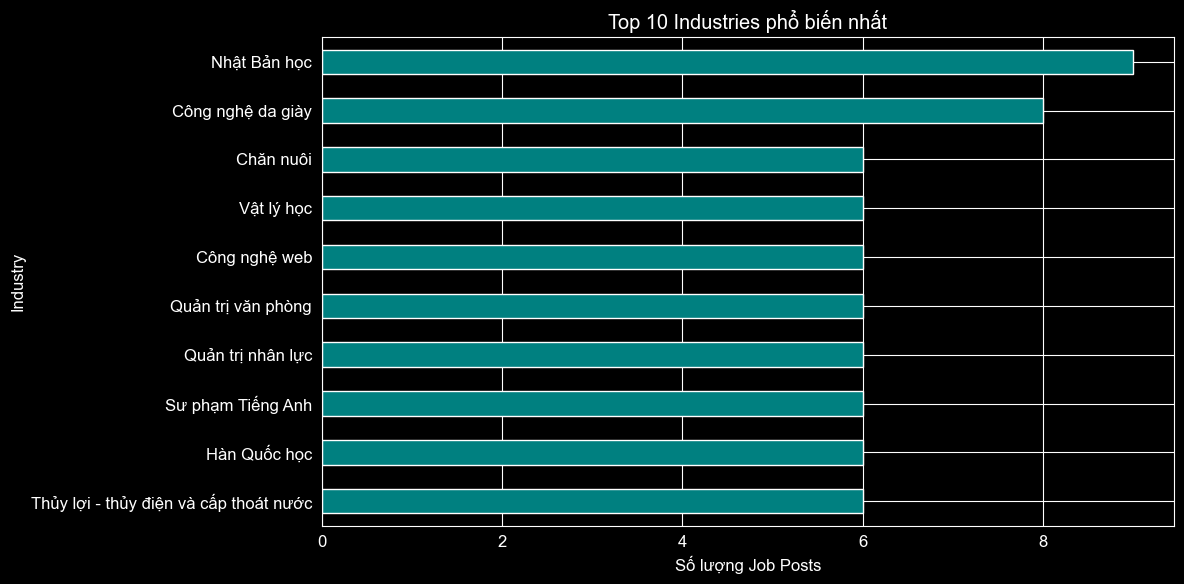

In [14]:
# Top 10 industries phổ biến nhất
top_industries = job_posts_full['industry_name'].value_counts().head(10)
plt.figure(figsize=(12, 6))
top_industries.plot(kind='barh', color='teal')
plt.xlabel('Số lượng Job Posts')
plt.ylabel('Industry')
plt.title('Top 10 Industries phổ biến nhất')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


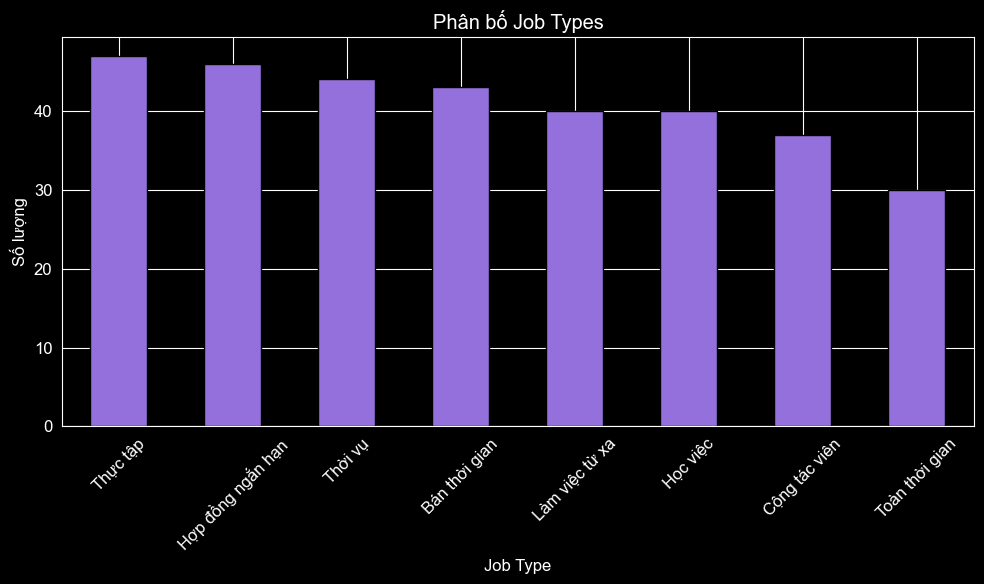

In [15]:
# Phân bố Job Types
job_type_dist = job_posts_full['job_type_name'].value_counts()
plt.figure(figsize=(10, 6))
job_type_dist.plot(kind='bar', color='mediumpurple', edgecolor='black')
plt.xlabel('Job Type')
plt.ylabel('Số lượng')
plt.title('Phân bố Job Types')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


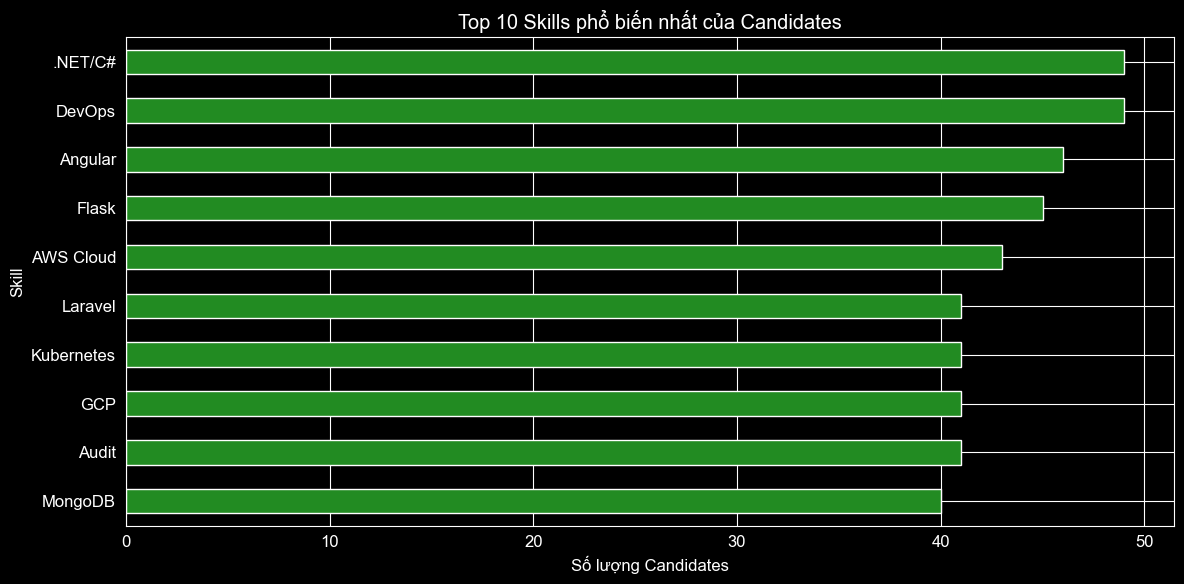

In [16]:
# Top 10 skills phổ biến nhất (candidates)
all_candidate_skills = candidates_skills.merge(skills[['id', 'name']], left_on='skills_id', right_on='id')
top_candidate_skills = all_candidate_skills['name'].value_counts().head(10)

plt.figure(figsize=(12, 6))
top_candidate_skills.plot(kind='barh', color='forestgreen')
plt.xlabel('Số lượng Candidates')
plt.ylabel('Skill')
plt.title('Top 10 Skills phổ biến nhất của Candidates')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


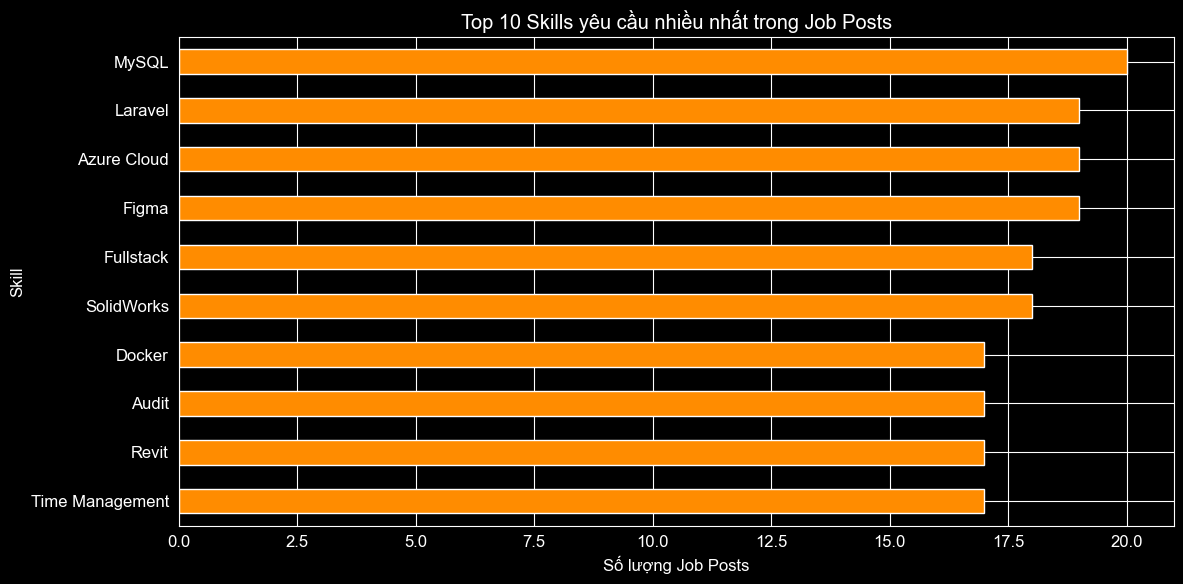

In [17]:
# Top 10 skills yêu cầu nhiều nhất (job posts)
all_job_skills = job_posts_skills.merge(skills[['id', 'name']], left_on='skills_id', right_on='id')
top_job_skills = all_job_skills['name'].value_counts().head(10)

plt.figure(figsize=(12, 6))
top_job_skills.plot(kind='barh', color='darkorange')
plt.xlabel('Số lượng Job Posts')
plt.ylabel('Skill')
plt.title('Top 10 Skills yêu cầu nhiều nhất trong Job Posts')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


# Phần 3: TIỀN XỬ LÝ DỮ LIỆU


## 3.1. Tạo DataFrame tổng hợp cho Candidates

In [18]:
# Merge tất cả thông tin candidate
df_candidates = candidates_full.merge(candidate_skills_agg, left_on='id', right_on='candidate_id', how='left')
df_candidates = df_candidates.drop(columns=['candidate_id'], errors='ignore')

# Chọn các cột cần thiết cho recommendation
df_candidates = df_candidates[['id', 'summary', 'education', 'expect_salary', 'skills_list']].copy()
df_candidates.columns = ['candidate_id', 'summary', 'education', 'expect_salary', 'skills']

print("=== CANDIDATES DATAFRAME FOR RECOMMENDATION ===")
print(f"Shape: {df_candidates.shape}")
df_candidates.head()


=== CANDIDATES DATAFRAME FOR RECOMMENDATION ===
Shape: (100, 5)


,candidate_id,summary,education,expect_salary,skills
0,00fc28fb-86af-440c-ae99-6b98ad7debdb,Frontend Developer với ReactJS,,39000000.0,"Python, Cyber Security, MongoDB, Laravel, Flask, Angular, Teamwork, Django, iOS, Spring Boot, SE..."
1,04149279-92bf-422b-a0df-798f3611a1c5,Frontend Developer,Thạc sĩ CNTT,35000000.0,"ASP.NET, Computer Vision, Python, Creativity, TypeScript, Flask, Digital Marketing, Teamwork, Me..."
2,0746450e-92c6-4c1a-8fc7-ea2ee9cc6d42,Nhân sự tuyển dụng IT.,Cử nhân Quản trị kinh doanh,15000000.0,"ReactJS, Class Management, Creativity, Cyber Security, MySQL, Revit, Laravel, Flask, Angular, An..."
3,0944b2dc-7e8f-4e92-9263-596d6b978946,"Kỹ sư phần mềm, làm việc với hệ thống lớn.",Đại học Khoa học Tự nhiên,18000000.0,"Machine Learning, ReactJS, Class Management, Python, Creativity, Cyber Security, JavaScript, Mon..."
4,0dffbd1a-2d8a-431f-ae68-fd314fbe46dc,Nhân sự tuyển dụng IT.,Cử nhân Công nghệ thông tin,0.0,"Python, Creativity, Revit, MongoDB, Laravel, Digital Marketing, Android, Audit, SQL, Time Manage..."


## 3.2. Tạo DataFrame tổng hợp cho Job Posts

In [19]:
# Merge tất cả thông tin job posts
df_jobs = job_posts_full.merge(job_skills_agg, left_on='id', right_on='job_post_id', how='left')
df_jobs = df_jobs.drop(columns=['job_post_id'], errors='ignore')

# Chọn các cột cần thiết cho recommendation
df_jobs = df_jobs[['id', 'title', 'description', 'salary', 'salary_type', 'industry_name', 'job_type_name', 'level_name', 'skills_list']].copy()
df_jobs.columns = ['job_id', 'title', 'description', 'salary', 'salary_type', 'industry', 'job_type', 'level', 'skills']

print("=== JOBS DATAFRAME FOR RECOMMENDATION ===")
print(f"Shape: {df_jobs.shape}")
df_jobs.head()


=== JOBS DATAFRAME FOR RECOMMENDATION ===
Shape: (327, 9)


,job_id,title,description,salary,salary_type,industry,job_type,level,skills
0,002d35b1-1ff1-45f8-b0ef-7897d2584554,Lập trình viên Python,Hiểu biết về Machine Learning,25000000.0,PROJECT,Sư phạm Lịch sử,Hợp đồng ngắn hạn,Nhà văn / Biên tập viên (Writer),"Teamwork, NodeJS, Business Analysis, Deep Learning"
1,007cd194-f5de-4af1-b299-ffe7dc314e76,Lập trình viên Python,Yêu cầu kinh nghiệm 2 năm,10000000.0,MONTHS,Kỹ thuật Robot,Thời vụ,Hiệu trưởng / Giám đốc trung tâm (Principal),NaN
2,0138730f-d1f2-49c4-a72b-582f8a75ba48,Kỹ sư dữ liệu,Có thể làm việc nhóm tốt,18000000.0,NaN,Kỹ thuật điều khiển và tự động hóa,Cộng tác viên,Giám đốc tài chính (CFO),"Machine Learning, Docker, Spring Boot, Azure Cloud, VueJS"
3,0181d9a3-aa61-490e-b8f7-aa219e80e74a,Kỹ sư AI,undefined,18000000.0,NEGOTIATION,Xây dựng cảng - công trình biển,Thời vụ,Giám sát viên (Supervisor),"VueJS, Accounting"
4,03d649a5-a55b-4162-9064-4e54c6d43a11,Kỹ sư dữ liệu,Hiểu biết về Machine Learning,20000000.0,NaN,An ninh mạng,Bán thời gian,Chuyên gia (Expert),NaN


## 3.3. Xử lý Missing Values

In [20]:
# Xử lý missing values cho candidates
df_candidates['summary'] = df_candidates['summary'].fillna('')
df_candidates['education'] = df_candidates['education'].fillna('')
df_candidates['expect_salary'] = df_candidates['expect_salary'].fillna(0)
df_candidates['skills'] = df_candidates['skills'].fillna('')

# Clean text - loại bỏ khoảng trắng thừa
df_candidates['summary'] = df_candidates['summary'].str.strip()
df_candidates['education'] = df_candidates['education'].str.strip()
df_candidates['skills'] = df_candidates['skills'].str.strip()

print("=== CANDIDATES AFTER HANDLING MISSING VALUES ===")
print(df_candidates.isnull().sum())

=== CANDIDATES AFTER HANDLING MISSING VALUES ===
candidate_id     0
summary          0
education        0
expect_salary    0
skills           0
dtype: int64


In [21]:
# Xử lý missing values cho jobs
df_jobs['description'] = df_jobs['description'].fillna('')
df_jobs['salary'] = df_jobs['salary'].fillna(0)
df_jobs['salary_type'] = df_jobs['salary_type'].fillna('UNKNOWN')
df_jobs['industry'] = df_jobs['industry'].fillna('Khác')
df_jobs['job_type'] = df_jobs['job_type'].fillna('Khác')
df_jobs['level'] = df_jobs['level'].fillna('Khác')
df_jobs['skills'] = df_jobs['skills'].fillna('')

# Clean text
df_jobs['description'] = df_jobs['description'].str.strip()
df_jobs['skills'] = df_jobs['skills'].str.strip()

print("=== JOBS AFTER HANDLING MISSING VALUES ===")
print(df_jobs.isnull().sum())


=== JOBS AFTER HANDLING MISSING VALUES ===
job_id          0
title          39
description     0
salary          0
salary_type     0
industry        0
job_type        0
level           0
skills          0
dtype: int64


## 3.4. Tạo Text Features tổng hợp

In [22]:
# Tạo combined text cho candidates (summary + education + skills)
df_candidates['combined_text'] = (
    df_candidates['summary'].astype(str) + ' ' +
    df_candidates['education'].astype(str) + ' ' +
    df_candidates['skills'].astype(str)
).str.strip()

print("=== CANDIDATE COMBINED TEXT SAMPLE ===")
for i, row in df_candidates.head(3).iterrows():
    print(f"Candidate {row['candidate_id'][:8]}...")
    print(f"  Combined text: {row['combined_text'][:200]}...")
    print()


=== CANDIDATE COMBINED TEXT SAMPLE ===
Candidate 00fc28fb...
  Combined text: Frontend Developer với ReactJS  Python, Cyber Security, MongoDB, Laravel, Flask, Angular, Teamwork, Django, iOS, Spring Boot, SEO, Time Management, Leadership, Business Analysis, Excel, VueJS, Deep Le...

Candidate 04149279...
  Combined text: Frontend Developer Thạc sĩ CNTT ASP.NET, Computer Vision, Python, Creativity, TypeScript, Flask, Digital Marketing, Teamwork, Medical Assistant, Time Management, GCP, Pentesting, Networking, PHP, Sale...

Candidate 0746450e...
  Combined text: Nhân sự tuyển dụng IT. Cử nhân Quản trị kinh doanh ReactJS, Class Management, Creativity, Cyber Security, MySQL, Revit, Laravel, Flask, Angular, Android, NodeJS, SQL, Time Management, GCP, Leadership,...



In [23]:
# Tạo combined text cho jobs (description + industry + job_type + level + skills)
df_jobs['combined_text'] = (
    df_jobs['description'].astype(str) + ' ' +
    df_jobs['industry'].astype(str) + ' ' +
    df_jobs['job_type'].astype(str) + ' ' +
    df_jobs['level'].astype(str) + ' ' +
    df_jobs['skills'].astype(str)
).str.strip()

print("=== JOB COMBINED TEXT SAMPLE ===")
for i, row in df_jobs.head(3).iterrows():
    print(f"Job: {row['title']}")
    print(f"  Combined text: {row['combined_text'][:200]}...")
    print()


=== JOB COMBINED TEXT SAMPLE ===
Job: Lập trình viên Python
  Combined text: Hiểu biết về Machine Learning Sư phạm Lịch sử Hợp đồng ngắn hạn Nhà văn / Biên tập viên (Writer) Teamwork, NodeJS, Business Analysis, Deep Learning...

Job: Lập trình viên Python
  Combined text: Yêu cầu kinh nghiệm 2 năm Kỹ thuật Robot Thời vụ Hiệu trưởng / Giám đốc trung tâm (Principal)...

Job: Kỹ sư dữ liệu
  Combined text: Có thể làm việc nhóm tốt Kỹ thuật điều khiển và tự động hóa Cộng tác viên Giám đốc tài chính (CFO) Machine Learning, Docker, Spring Boot, Azure Cloud, VueJS...



## 3.5. Chuẩn hóa Salary Features

In [24]:
# Chuẩn hóa expect_salary và salary về cùng thang đo [0, 1]
scaler = MinMaxScaler()

# Lọc salary hợp lệ (> 0) để fit scaler
all_salaries = pd.concat([
    df_candidates[df_candidates['expect_salary'] > 0]['expect_salary'],
    df_jobs[df_jobs['salary'] > 0]['salary']
])

scaler.fit(all_salaries.values.reshape(-1, 1))

# Transform
df_candidates['salary_normalized'] = df_candidates['expect_salary'].apply(
    lambda x: scaler.transform([[x]])[0][0] if x > 0 else 0.5  # 0.5 cho missing salary
)

df_jobs['salary_normalized'] = df_jobs['salary'].apply(
    lambda x: scaler.transform([[x]])[0][0] if x > 0 else 0.5
)

print("=== SALARY NORMALIZATION ===")
print(f"Candidate salary range: {df_candidates['salary_normalized'].min():.3f} - {df_candidates['salary_normalized'].max():.3f}")
print(f"Job salary range: {df_jobs['salary_normalized'].min():.3f} - {df_jobs['salary_normalized'].max():.3f}")


=== SALARY NORMALIZATION ===
Candidate salary range: 0.159 - 0.780
Job salary range: 0.000 - 1.000


# Phần 4: XÂY DỰNG VECTOR CANDIDATE & JOB


## 4.1. TF-IDF Vectorization cho Text Features

In [25]:
# Tạo TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=1000,          # Giới hạn số features
    ngram_range=(1, 2),         # Unigrams và bigrams
    min_df=2,                   # Loại bỏ từ xuất hiện < 2 lần
    max_df=0.95,                # Loại bỏ từ xuất hiện > 95% documents
    stop_words=None             # Giữ nguyên tiếng Việt
)

# Fit trên tất cả combined text
all_text = pd.concat([df_candidates['combined_text'], df_jobs['combined_text']])
tfidf_vectorizer.fit(all_text)

# Transform
candidate_tfidf = tfidf_vectorizer.transform(df_candidates['combined_text'])
job_tfidf = tfidf_vectorizer.transform(df_jobs['combined_text'])

print("=== TF-IDF VECTORIZATION ===")
print(f"Vocabulary size: {len(tfidf_vectorizer.vocabulary_)}")
print(f"Candidate TF-IDF shape: {candidate_tfidf.shape}")
print(f"Job TF-IDF shape: {job_tfidf.shape}")


=== TF-IDF VECTORIZATION ===
Vocabulary size: 1000
Candidate TF-IDF shape: (100, 1000)
Job TF-IDF shape: (327, 1000)


In [26]:
# Xem top features
feature_names = tfidf_vectorizer.get_feature_names_out()
print("\n=== SAMPLE TF-IDF FEATURES ===")
print(feature_names[:50])



=== SAMPLE TF-IDF FEATURES ===
['academic' 'academic director' 'accountant' 'accounting'
 'accounting fullstack' 'accounting video' 'an' 'analysis'
 'analysis azure' 'analysis customer' 'analysis devops' 'analysis excel'
 'analysis figma' 'analysis php' 'analysis sales' 'analysis teaching'
 'analysis ui' 'android' 'android audit' 'android ios' 'android nodejs'
 'angular' 'angular marketing' 'angular medical' 'angular net'
 'angular teamwork' 'anh' 'api' 'api xử' 'architect' 'artist' 'asp'
 'asp net' 'assistant' 'assistant django' 'assistant ios'
 'assistant marketing' 'audit' 'audit aws' 'audit nodejs' 'audit seo'
 'audit spring' 'audit sql' 'audit time' 'autocad' 'autocad docker'
 'autocad laravel' 'autocad mongodb' 'aws' 'aws cloud']


## 4.2. Skill-based Vectorization (Binary Encoding)

In [27]:
# Tạo binary encoding cho skills
all_skills_list = skills['name'].tolist()
print(f"Total unique skills: {len(all_skills_list)}")

def encode_skills(skill_string, all_skills):
    """Encode skills thành binary vector"""
    if pd.isna(skill_string) or skill_string == '':
        return [0] * len(all_skills)

    candidate_skills = [s.strip() for s in skill_string.split(',')]
    return [1 if skill in candidate_skills else 0 for skill in all_skills]

# Encode skills cho candidates
candidate_skills_encoded = df_candidates['skills'].apply(lambda x: encode_skills(x, all_skills_list))
candidate_skills_matrix = csr_matrix(np.array(candidate_skills_encoded.tolist()))

# Encode skills cho jobs
job_skills_encoded = df_jobs['skills'].apply(lambda x: encode_skills(x, all_skills_list))
job_skills_matrix = csr_matrix(np.array(job_skills_encoded.tolist()))

print("=== SKILLS ENCODING ===")
print(f"Candidate skills matrix shape: {candidate_skills_matrix.shape}")
print(f"Job skills matrix shape: {job_skills_matrix.shape}")


Total unique skills: 62
=== SKILLS ENCODING ===
Candidate skills matrix shape: (100, 62)
Job skills matrix shape: (327, 62)


## 4.3. Salary Feature Vector

In [28]:
# Tạo salary feature vector
candidate_salary_vector = csr_matrix(df_candidates['salary_normalized'].values.reshape(-1, 1))
job_salary_vector = csr_matrix(df_jobs['salary_normalized'].values.reshape(-1, 1))

print("=== SALARY VECTORS ===")
print(f"Candidate salary vector shape: {candidate_salary_vector.shape}")
print(f"Job salary vector shape: {job_salary_vector.shape}")


=== SALARY VECTORS ===
Candidate salary vector shape: (100, 1)
Job salary vector shape: (327, 1)


## 4.4. Kết hợp tất cả Features thành Final Vector

In [29]:
# Định nghĩa trọng số cho mỗi loại feature
WEIGHT_TFIDF = 0.4      # Text similarity (summary, education, description)
WEIGHT_SKILLS = 0.45    # Skills matching
WEIGHT_SALARY = 0.15    # Salary compatibility

# Kết hợp features với trọng số
candidate_final_vector = hstack([
    candidate_tfidf * WEIGHT_TFIDF,
    candidate_skills_matrix * WEIGHT_SKILLS,
    candidate_salary_vector * WEIGHT_SALARY
])

job_final_vector = hstack([
    job_tfidf * WEIGHT_TFIDF,
    job_skills_matrix * WEIGHT_SKILLS,
    job_salary_vector * WEIGHT_SALARY
])

print("=== FINAL VECTORS ===")
print(f"Candidate final vector shape: {candidate_final_vector.shape}")
print(f"Job final vector shape: {job_final_vector.shape}")
print(f"\nFeature breakdown:")
print(f"  - TF-IDF features: {candidate_tfidf.shape[1]} (weight: {WEIGHT_TFIDF})")
print(f"  - Skills features: {candidate_skills_matrix.shape[1]} (weight: {WEIGHT_SKILLS})")
print(f"  - Salary features: {candidate_salary_vector.shape[1]} (weight: {WEIGHT_SALARY})")


=== FINAL VECTORS ===
Candidate final vector shape: (100, 1063)
Job final vector shape: (327, 1063)

Feature breakdown:
  - TF-IDF features: 1000 (weight: 0.4)
  - Skills features: 62 (weight: 0.45)
  - Salary features: 1 (weight: 0.15)


# Phần 5: MÔ HÌNH GỢI Ý (SIMILARITY MODEL)


## 5.1. Tính Cosine Similarity

In [30]:
# Tính cosine similarity giữa tất cả candidates và jobs
similarity_matrix = cosine_similarity(candidate_final_vector, job_final_vector)

print("=== SIMILARITY MATRIX ===")
print(f"Shape: {similarity_matrix.shape}")
print(f"Min similarity: {similarity_matrix.min():.4f}")
print(f"Max similarity: {similarity_matrix.max():.4f}")
print(f"Mean similarity: {similarity_matrix.mean():.4f}")


=== SIMILARITY MATRIX ===
Shape: (100, 327)
Min similarity: 0.0000
Max similarity: 0.5263
Mean similarity: 0.0893


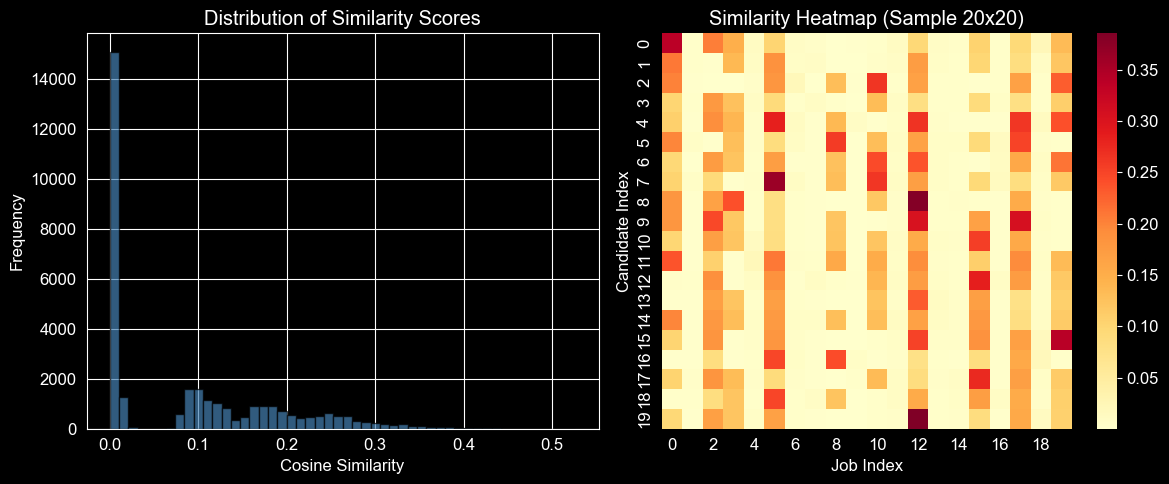

In [31]:
# Visualize similarity distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(similarity_matrix.flatten(), bins=50, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
plt.title('Distribution of Similarity Scores')

plt.subplot(1, 2, 2)
# Heatmap sample (first 20 candidates x first 20 jobs)
sns.heatmap(similarity_matrix[:20, :20], cmap='YlOrRd', annot=False)
plt.xlabel('Job Index')
plt.ylabel('Candidate Index')
plt.title('Similarity Heatmap (Sample 20x20)')

plt.tight_layout()
plt.show()


## 5.2. Hàm Recommendation

In [32]:
def get_job_recommendations(candidate_id, top_n=10, min_similarity=0.0):
    """
    Gợi ý top N jobs cho một candidate dựa trên similarity score

    Parameters:
    -----------
    candidate_id : str
        ID của candidate
    top_n : int
        Số lượng jobs gợi ý
    min_similarity : float
        Ngưỡng similarity tối thiểu

    Returns:
    --------
    DataFrame với thông tin các jobs được gợi ý
    """
    # Tìm index của candidate
    candidate_idx = df_candidates[df_candidates['candidate_id'] == candidate_id].index

    if len(candidate_idx) == 0:
        print(f"Candidate {candidate_id} not found!")
        return None

    candidate_idx = candidate_idx[0]

    # Lấy similarity scores cho candidate này
    scores = similarity_matrix[candidate_idx]

    # Tạo DataFrame kết quả
    job_scores = pd.DataFrame({
        'job_id': df_jobs['job_id'],
        'title': df_jobs['title'],
        'description': df_jobs['description'],
        'salary': df_jobs['salary'],
        'industry': df_jobs['industry'],
        'job_type': df_jobs['job_type'],
        'level': df_jobs['level'],
        'skills': df_jobs['skills'],
        'similarity_score': scores
    })

    # Lọc theo min_similarity và sort
    job_scores = job_scores[job_scores['similarity_score'] >= min_similarity]
    job_scores = job_scores.sort_values('similarity_score', ascending=False)

    return job_scores.head(top_n)


In [33]:
def get_candidate_recommendations(job_id, top_n=10, min_similarity=0.0):
    """
    Gợi ý top N candidates cho một job post dựa trên similarity score

    Parameters:
    -----------
    job_id : str
        ID của job post
    top_n : int
        Số lượng candidates gợi ý
    min_similarity : float
        Ngưỡng similarity tối thiểu

    Returns:
    --------
    DataFrame với thông tin các candidates được gợi ý
    """
    # Tìm index của job
    job_idx = df_jobs[df_jobs['job_id'] == job_id].index

    if len(job_idx) == 0:
        print(f"Job {job_id} not found!")
        return None

    job_idx = job_idx[0]

    # Lấy similarity scores cho job này (transpose của matrix)
    scores = similarity_matrix[:, job_idx]

    # Tạo DataFrame kết quả
    candidate_scores = pd.DataFrame({
        'candidate_id': df_candidates['candidate_id'],
        'summary': df_candidates['summary'],
        'education': df_candidates['education'],
        'expect_salary': df_candidates['expect_salary'],
        'skills': df_candidates['skills'],
        'similarity_score': scores
    })

    # Lọc theo min_similarity và sort
    candidate_scores = candidate_scores[candidate_scores['similarity_score'] >= min_similarity]
    candidate_scores = candidate_scores.sort_values('similarity_score', ascending=False)

    return candidate_scores.head(top_n)


## 5.3. Demo Recommendation

In [34]:
# Chọn một candidate để demo
sample_candidate_id = df_candidates.iloc[0]['candidate_id']
print("=== CANDIDATE INFORMATION ===")
candidate_info = df_candidates[df_candidates['candidate_id'] == sample_candidate_id].iloc[0]
print(f"ID: {candidate_info['candidate_id']}")
print(f"Summary: {candidate_info['summary']}")
print(f"Education: {candidate_info['education']}")
print(f"Expected Salary: {candidate_info['expect_salary']:,.0f} VND")
print(f"Skills: {candidate_info['skills']}")


=== CANDIDATE INFORMATION ===
ID: 00fc28fb-86af-440c-ae99-6b98ad7debdb
Summary: Frontend Developer với ReactJS
Education: 
Expected Salary: 39,000,000 VND
Skills: Python, Cyber Security, MongoDB, Laravel, Flask, Angular, Teamwork, Django, iOS, Spring Boot, SEO, Time Management, Leadership, Business Analysis, Excel, VueJS, Deep Learning


In [35]:
# Gợi ý jobs cho candidate
print("\n=== TOP 10 JOB RECOMMENDATIONS ===")
recommendations = get_job_recommendations(sample_candidate_id, top_n=10)
if recommendations is not None:
    for idx, row in recommendations.iterrows():
        print(f"\n{idx+1}. {row['title']}")
        print(f"   Similarity: {row['similarity_score']:.4f}")
        print(f"   Salary: {row['salary']:,.0f} VND")
        print(f"   Industry: {row['industry']}")
        print(f"   Level: {row['level']}")
        print(f"   Skills: {row['skills'][:100]}...")



=== TOP 10 JOB RECOMMENDATIONS ===

1. Lập trình viên Python
   Similarity: 0.3385
   Salary: 25,000,000 VND
   Industry: Sư phạm Lịch sử
   Level: Nhà văn / Biên tập viên (Writer)
   Skills: Teamwork, NodeJS, Business Analysis, Deep Learning...

315. Kỹ sư AI
   Similarity: 0.3362
   Salary: -1 VND
   Industry: Kỹ thuật Robot
   Level: Kế toán viên (Accountant)
   Skills: MySQL, Django, Leadership, Deep Learning...

139. Content SEO
   Similarity: 0.3012
   Salary: 50,000 VND
   Industry: Quan hệ công chúng
   Level: Giám đốc tài chính (CFO)
   Skills: Python, SEO, Time Management, Problem Solving, Teaching...

322. Lập trình viên Mobile Flutter
   Similarity: 0.3009
   Salary: 15,000,000 VND
   Industry: Kỹ thuật công trình
   Level: Quản lý cấp cao (Senior Manager)
   Skills: VueJS, Deep Learning...

163. Lập trình viên Frontend React
   Similarity: 0.2941
   Salary: 25,000,000 VND
   Industry: Dược học
   Level: Giám đốc (Director)
   Skills: Python, Teamwork...

26. nan
   Simila

In [36]:
# Demo ngược lại: tìm candidates phù hợp cho một job
sample_job_id = df_jobs.iloc[0]['job_id']
print("=== JOB INFORMATION ===")
job_info = df_jobs[df_jobs['job_id'] == sample_job_id].iloc[0]
print(f"Title: {job_info['title']}")
print(f"Description: {job_info['description']}")
print(f"Salary: {job_info['salary']:,.0f} VND")
print(f"Industry: {job_info['industry']}")
print(f"Skills: {job_info['skills']}")

print("\n=== TOP 10 CANDIDATE RECOMMENDATIONS ===")
candidate_recs = get_candidate_recommendations(sample_job_id, top_n=10)
if candidate_recs is not None:
    for idx, row in candidate_recs.iterrows():
        print(f"\n{idx+1}. Candidate: {row['candidate_id'][:20]}...")
        print(f"   Similarity: {row['similarity_score']:.4f}")
        print(f"   Summary: {row['summary'][:80]}...")
        print(f"   Expected Salary: {row['expect_salary']:,.0f} VND")
        print(f"   Skills: {row['skills'][:80]}...")


=== JOB INFORMATION ===
Title: Lập trình viên Python
Description: Hiểu biết về Machine Learning
Salary: 25,000,000 VND
Industry: Sư phạm Lịch sử
Skills: Teamwork, NodeJS, Business Analysis, Deep Learning

=== TOP 10 CANDIDATE RECOMMENDATIONS ===

45. Candidate: 6ebb70ed-45b0-4d3d-a...
   Similarity: 0.4010
   Summary: Frontend developer ReactJS....
   Expected Salary: 16,000,000 VND
   Skills: ASP.NET, Class Management, Kubernetes, TypeScript, MySQL, MongoDB, Flask, Digita...

98. Candidate: f03e8b35-4c37-426e-8...
   Similarity: 0.3757
   Summary: ...
   Expected Salary: 0 VND
   Skills: Machine Learning, Python, Angular, Teamwork, Marketing, iOS, SEO, Leadership, Bu...

55. Candidate: 8ae2d0e1-4548-4802-b...
   Similarity: 0.3544
   Summary: ...
   Expected Salary: 18,000,000 VND
   Skills: Class Management, Kubernetes, MySQL, Revit, MongoDB, Digital Marketing, Angular,...

1. Candidate: 00fc28fb-86af-440c-a...
   Similarity: 0.3385
   Summary: Frontend Developer với ReactJS...
   Ex

# Phần 6: ĐÁNH GIÁ MÔ HÌNH (OFFLINE EVALUATION)


## 6.1. Phương pháp đánh giá

Vì chúng ta không có ground truth (dữ liệu về các ứng tuyển thực tế), chúng ta sẽ đánh giá mô hình bằng các phương pháp sau:

1. **Coverage**: Tỷ lệ jobs/candidates được recommend ít nhất 1 lần
2. **Diversity**: Đa dạng các recommendations
3. **Skill Match Rate**: Tỷ lệ skills khớp giữa candidate và job được recommend
4. **Salary Compatibility**: Độ phù hợp về mức lương


In [37]:
def evaluate_recommendations():
    """Đánh giá toàn diện hệ thống recommendation"""

    results = {
        'coverage': {},
        'diversity': {},
        'skill_match': {},
        'salary_compatibility': {}
    }

    # 1. Coverage Analysis
    print("=== 1. COVERAGE ANALYSIS ===")

    # Đếm số jobs được recommend cho mỗi candidate (top 10)
    recommended_jobs = set()
    for candidate_id in df_candidates['candidate_id']:
        recs = get_job_recommendations(candidate_id, top_n=10)
        if recs is not None:
            recommended_jobs.update(recs['job_id'].tolist())

    job_coverage = len(recommended_jobs) / len(df_jobs) * 100
    results['coverage']['job_coverage'] = job_coverage
    print(f"Job Coverage: {job_coverage:.2f}% ({len(recommended_jobs)}/{len(df_jobs)} jobs)")

    # Đếm số candidates được recommend cho mỗi job (top 10)
    recommended_candidates = set()
    for job_id in df_jobs['job_id']:
        recs = get_candidate_recommendations(job_id, top_n=10)
        if recs is not None:
            recommended_candidates.update(recs['candidate_id'].tolist())

    candidate_coverage = len(recommended_candidates) / len(df_candidates) * 100
    results['coverage']['candidate_coverage'] = candidate_coverage
    print(f"Candidate Coverage: {candidate_coverage:.2f}% ({len(recommended_candidates)}/{len(df_candidates)} candidates)")

    return results

# Run evaluation
evaluation_results = evaluate_recommendations()


=== 1. COVERAGE ANALYSIS ===
Job Coverage: 54.43% (178/327 jobs)
Candidate Coverage: 100.00% (100/100 candidates)


## 6.2. Skill Match Rate Evaluation

=== SKILL MATCH RATE ===
Average Skill Match Rate (Jaccard): 0.1773
Standard Deviation: 0.0287
Min: 0.1154, Max: 0.3125


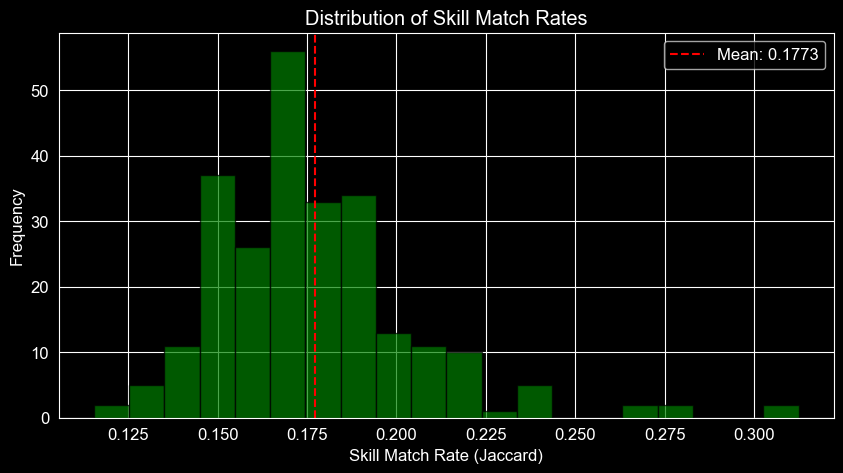

In [38]:
def calculate_skill_match_rate(sample_size=50):
    """Tính tỷ lệ skills match giữa candidate và recommended jobs"""

    # Sample random candidates
    sample_candidates = df_candidates.sample(min(sample_size, len(df_candidates)))

    match_rates = []

    for _, candidate in sample_candidates.iterrows():
        candidate_skills = set([s.strip() for s in str(candidate['skills']).split(',') if s.strip()])

        if len(candidate_skills) == 0:
            continue

        recs = get_job_recommendations(candidate['candidate_id'], top_n=5)
        if recs is None or len(recs) == 0:
            continue

        for _, job in recs.iterrows():
            job_skills = set([s.strip() for s in str(job['skills']).split(',') if s.strip()])

            if len(job_skills) == 0:
                continue

            # Calculate Jaccard similarity for skills
            intersection = len(candidate_skills.intersection(job_skills))
            union = len(candidate_skills.union(job_skills))

            if union > 0:
                match_rate = intersection / union
                match_rates.append(match_rate)

    if len(match_rates) > 0:
        avg_match_rate = np.mean(match_rates)
        std_match_rate = np.std(match_rates)
        print(f"=== SKILL MATCH RATE ===")
        print(f"Average Skill Match Rate (Jaccard): {avg_match_rate:.4f}")
        print(f"Standard Deviation: {std_match_rate:.4f}")
        print(f"Min: {min(match_rates):.4f}, Max: {max(match_rates):.4f}")

        # Visualize
        plt.figure(figsize=(10, 5))
        plt.hist(match_rates, bins=20, edgecolor='black', alpha=0.7, color='green')
        plt.xlabel('Skill Match Rate (Jaccard)')
        plt.ylabel('Frequency')
        plt.title('Distribution of Skill Match Rates')
        plt.axvline(avg_match_rate, color='red', linestyle='--', label=f'Mean: {avg_match_rate:.4f}')
        plt.legend()
        plt.show()

        return avg_match_rate

    return 0

skill_match_rate = calculate_skill_match_rate()


## 6.3. Salary Compatibility Evaluation

=== SALARY COMPATIBILITY ===
Total pairs evaluated: 139
Compatible pairs (job salary >= 80% expected): 71 (51.08%)
Average salary difference: 0.25%


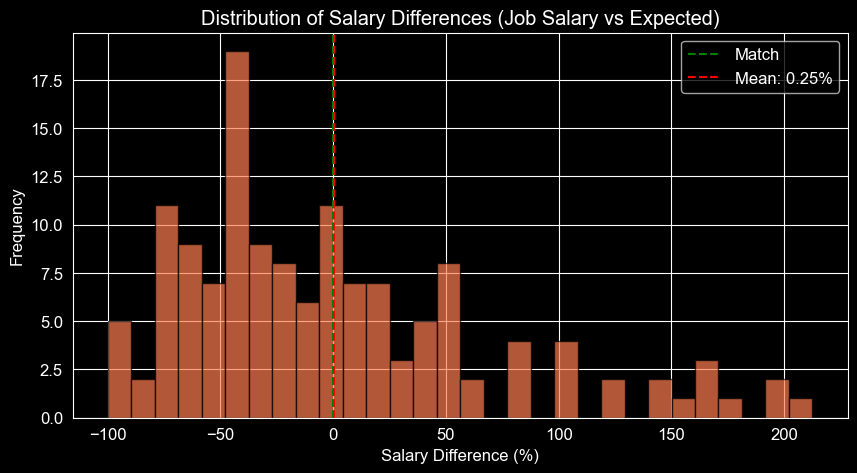

In [39]:
def calculate_salary_compatibility(sample_size=50):
    """Đánh giá độ phù hợp về mức lương"""

    sample_candidates = df_candidates[df_candidates['expect_salary'] > 0].sample(
        min(sample_size, len(df_candidates[df_candidates['expect_salary'] > 0]))
    )

    salary_diffs = []
    compatible_count = 0
    total_count = 0

    for _, candidate in sample_candidates.iterrows():
        expect_salary = candidate['expect_salary']

        recs = get_job_recommendations(candidate['candidate_id'], top_n=5)
        if recs is None or len(recs) == 0:
            continue

        for _, job in recs.iterrows():
            job_salary = job['salary']
            if job_salary > 0:
                total_count += 1
                diff_percent = (job_salary - expect_salary) / expect_salary * 100
                salary_diffs.append(diff_percent)

                # Compatible nếu job salary >= 80% expect salary
                if job_salary >= expect_salary * 0.8:
                    compatible_count += 1

    if len(salary_diffs) > 0:
        print(f"=== SALARY COMPATIBILITY ===")
        print(f"Total pairs evaluated: {total_count}")
        print(f"Compatible pairs (job salary >= 80% expected): {compatible_count} ({compatible_count/total_count*100:.2f}%)")
        print(f"Average salary difference: {np.mean(salary_diffs):.2f}%")

        # Visualize
        plt.figure(figsize=(10, 5))
        plt.hist(salary_diffs, bins=30, edgecolor='black', alpha=0.7, color='coral')
        plt.xlabel('Salary Difference (%)')
        plt.ylabel('Frequency')
        plt.title('Distribution of Salary Differences (Job Salary vs Expected)')
        plt.axvline(0, color='green', linestyle='--', label='Match')
        plt.axvline(np.mean(salary_diffs), color='red', linestyle='--', label=f'Mean: {np.mean(salary_diffs):.2f}%')
        plt.legend()
        plt.show()

        return compatible_count / total_count if total_count > 0 else 0

    return 0

salary_compatibility = calculate_salary_compatibility()


## 6.4. Diversity Evaluation

=== DIVERSITY ANALYSIS ===
Unique industries in recommendations: 76
Unique levels in recommendations: 42


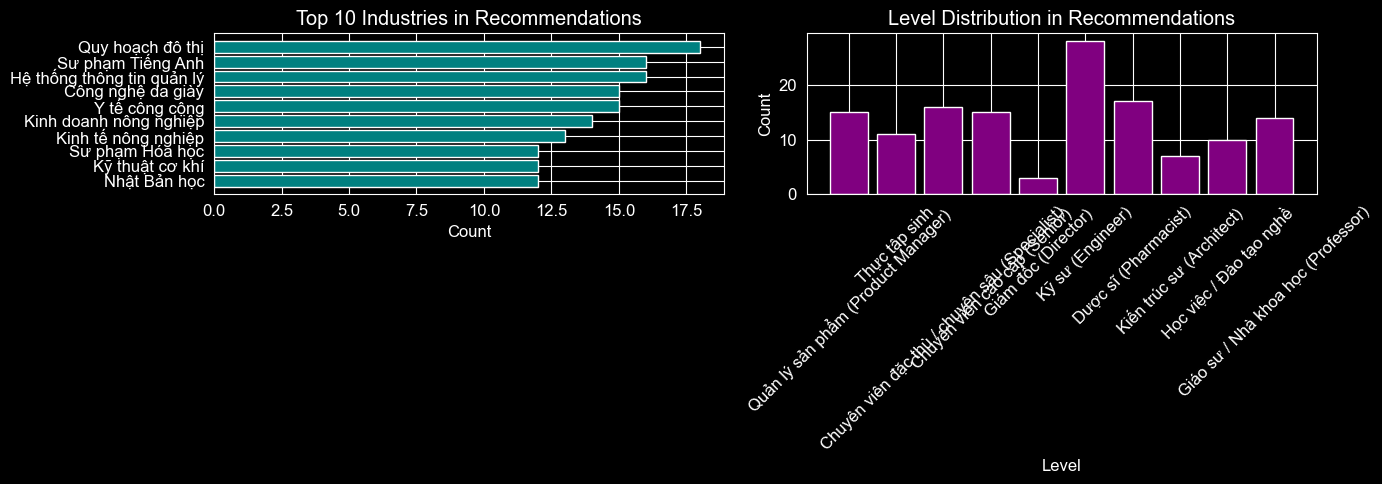


Diversity Score (Normalized Entropy): 0.9547


In [40]:
def calculate_diversity(sample_size=50):
    """Đánh giá độ đa dạng của recommendations"""

    sample_candidates = df_candidates.sample(min(sample_size, len(df_candidates)))

    # Đếm số lần mỗi industry xuất hiện trong recommendations
    industry_counts = {}
    level_counts = {}

    for _, candidate in sample_candidates.iterrows():
        recs = get_job_recommendations(candidate['candidate_id'], top_n=10)
        if recs is None:
            continue

        for _, job in recs.iterrows():
            industry = job['industry']
            level = job['level']

            industry_counts[industry] = industry_counts.get(industry, 0) + 1
            level_counts[level] = level_counts.get(level, 0) + 1

    print(f"=== DIVERSITY ANALYSIS ===")
    print(f"Unique industries in recommendations: {len(industry_counts)}")
    print(f"Unique levels in recommendations: {len(level_counts)}")

    # Visualize top industries
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    top_industries = dict(sorted(industry_counts.items(), key=lambda x: x[1], reverse=True)[:10])
    axes[0].barh(list(top_industries.keys()), list(top_industries.values()), color='teal')
    axes[0].set_xlabel('Count')
    axes[0].set_title('Top 10 Industries in Recommendations')
    axes[0].invert_yaxis()

    # Level distribution
    axes[1].bar(list(level_counts.keys())[:10], list(level_counts.values())[:10], color='purple')
    axes[1].set_xlabel('Level')
    axes[1].set_ylabel('Count')
    axes[1].set_title('Level Distribution in Recommendations')
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    # Calculate entropy as diversity measure
    total = sum(industry_counts.values())
    probs = [count/total for count in industry_counts.values()]
    entropy = -sum([p * np.log2(p) for p in probs if p > 0])
    max_entropy = np.log2(len(industry_counts))
    normalized_diversity = entropy / max_entropy if max_entropy > 0 else 0

    print(f"\nDiversity Score (Normalized Entropy): {normalized_diversity:.4f}")

    return normalized_diversity

diversity_score = calculate_diversity()


## 6.5. Summary Evaluation Results

In [41]:
print("=" * 60)
print("EVALUATION SUMMARY")
print("=" * 60)
print(f"\n1. COVERAGE:")
print(f"   - Job Coverage: {evaluation_results['coverage'].get('job_coverage', 'N/A'):.2f}%")
print(f"   - Candidate Coverage: {evaluation_results['coverage'].get('candidate_coverage', 'N/A'):.2f}%")

print(f"\n2. SKILL MATCH RATE:")
print(f"   - Average Jaccard Similarity: {skill_match_rate:.4f}")

print(f"\n3. SALARY COMPATIBILITY:")
print(f"   - Compatible Rate (≥80% expected): {salary_compatibility*100:.2f}%")

print(f"\n4. DIVERSITY:")
print(f"   - Normalized Diversity Score: {diversity_score:.4f}")

print("\n" + "=" * 60)


EVALUATION SUMMARY

1. COVERAGE:
   - Job Coverage: 54.43%
   - Candidate Coverage: 100.00%

2. SKILL MATCH RATE:
   - Average Jaccard Similarity: 0.1773

3. SALARY COMPATIBILITY:
   - Compatible Rate (≥80% expected): 51.08%

4. DIVERSITY:
   - Normalized Diversity Score: 0.9547



# Phần 7: TỔNG KẾT & HƯỚNG CẢI TIẾN


## 7.1. Tổng kết

### Những gì đã thực hiện:

1. **Data Processing**:
   - Load và merge dữ liệu từ nhiều bảng CSV
   - Xử lý missing values
   - Tạo combined text features

2. **Feature Engineering**:
   - TF-IDF vectorization cho text features (summary, education, description)
   - Binary encoding cho skills
   - Normalized salary features

3. **Recommendation Model**:
   - Content-based filtering sử dụng Cosine Similarity
   - Weighted combination của text, skills và salary features
   - Hỗ trợ cả job recommendation cho candidate và candidate recommendation cho job

4. **Evaluation**:
   - Coverage analysis
   - Skill match rate
   - Salary compatibility
   - Diversity measurement


## 7.2. Hạn chế hiện tại

1. **Cold Start Problem**:
   - Candidates/Jobs mới không có đủ thông tin để recommend chính xác

2. **Thiếu User Interaction Data**:
   - Không có dữ liệu về clicks, views, applications để đánh giá chính xác

3. **Text Processing hạn chế**:
   - Chưa có xử lý NLP tiếng Việt chuyên sâu (word segmentation, stopwords)

4. **Static Weights**:
   - Trọng số cho các features được set cố định


## 7.3. Hướng cải tiến khi có thêm data

### Ngắn hạn:
1. **Thêm Vietnamese NLP**:
   - Sử dụng underthesea hoặc VnCoreNLP cho word segmentation
   - Xử lý stopwords tiếng Việt

2. **Learning to Rank**:
   - Khi có click/apply data, train model để học trọng số tối ưu

### Trung hạn:
3. **Collaborative Filtering**:
   - Khi có application history, kết hợp CF với content-based
   - Matrix Factorization (SVD, NMF)

4. **Deep Learning Embeddings**:
   - Sử dụng PhoBERT cho Vietnamese text embeddings
   - Neural collaborative filtering

### Dài hạn:
5. **Hybrid Recommendation System**:
   - Kết hợp content-based + collaborative filtering + knowledge-based

6. **Real-time Personalization**:
   - A/B testing
   - Multi-armed bandits cho exploration/exploitation

7. **Contextual Recommendations**:
   - Location-based filtering
   - Time-based (urgency of job posts)
   - Career path progression


## 7.4. Export Model để sử dụng trong Production

In [42]:
import pickle
import os

# Tạo thư mục lưu model nếu chưa có
model_dir = "../saved_models"
os.makedirs(model_dir, exist_ok=True)

# Lưu các components cần thiết
model_components = {
    'tfidf_vectorizer': tfidf_vectorizer,
    'scaler': scaler,
    'all_skills_list': all_skills_list,
    'weights': {
        'tfidf': WEIGHT_TFIDF,
        'skills': WEIGHT_SKILLS,
        'salary': WEIGHT_SALARY
    }
}

# Lưu model components
with open(f"{model_dir}/recommendation_model.pkl", 'wb') as f:
    pickle.dump(model_components, f)

# Lưu processed data
processed_data = {
    'df_candidates': df_candidates,
    'df_jobs': df_jobs,
    'candidate_final_vector': candidate_final_vector,
    'job_final_vector': job_final_vector,
    'similarity_matrix': similarity_matrix
}

with open(f"{model_dir}/processed_data.pkl", 'wb') as f:
    pickle.dump(processed_data, f)

print(f"Model saved to {model_dir}/")
print(f"Files created:")
print(f"  - recommendation_model.pkl")
print(f"  - processed_data.pkl")


Model saved to ../saved_models/
Files created:
  - recommendation_model.pkl
  - processed_data.pkl


## 7.5. Hàm Load và Sử dụng Model

In [43]:
def load_recommendation_model(model_dir="../saved_models"):
    """Load saved model components"""
    with open(f"{model_dir}/recommendation_model.pkl", 'rb') as f:
        model_components = pickle.load(f)

    with open(f"{model_dir}/processed_data.pkl", 'rb') as f:
        processed_data = pickle.load(f)

    return model_components, processed_data

def recommend_jobs_for_candidate(candidate_id, model_dir="../saved_models", top_n=10):
    """
    Production-ready function để recommend jobs
    """
    _, processed_data = load_recommendation_model(model_dir)

    df_candidates = processed_data['df_candidates']
    df_jobs = processed_data['df_jobs']
    similarity_matrix = processed_data['similarity_matrix']

    candidate_idx = df_candidates[df_candidates['candidate_id'] == candidate_id].index
    if len(candidate_idx) == 0:
        return None

    candidate_idx = candidate_idx[0]
    scores = similarity_matrix[candidate_idx]

    result = df_jobs.copy()
    result['similarity_score'] = scores
    result = result.sort_values('similarity_score', ascending=False).head(top_n)

    return result[['job_id', 'title', 'salary', 'industry', 'level', 'skills', 'similarity_score']]

# Test function
print("=== TEST LOAD AND RECOMMEND ===")
test_recommendations = recommend_jobs_for_candidate(sample_candidate_id)
if test_recommendations is not None:
    print(test_recommendations.head())


=== TEST LOAD AND RECOMMEND ===
                                   job_id                          title  \
0    002d35b1-1ff1-45f8-b0ef-7897d2584554          Lập trình viên Python   
314  f72f20d4-8823-4064-8cc4-00210bec7637                       Kỹ sư AI   
138  6722a0d6-2ca9-4903-a57d-06625ae17e0f                    Content SEO   
321  fd4f194b-86d6-46fa-894b-faf54b92a824  Lập trình viên Mobile Flutter   
162  77d41ee7-c7f3-4bd9-a53a-b739ae248e12  Lập trình viên Frontend React   

         salary             industry                             level  \
0    25000000.0      Sư phạm Lịch sử  Nhà văn / Biên tập viên (Writer)   
314        -1.0       Kỹ thuật Robot         Kế toán viên (Accountant)   
138     50000.0   Quan hệ công chúng          Giám đốc tài chính (CFO)   
321  15000000.0  Kỹ thuật công trình  Quản lý cấp cao (Senior Manager)   
162  25000000.0             Dược học               Giám đốc (Director)   

                                                      skills  simi

## 7.6. Kết luận

Hệ thống recommendation đã được xây dựng hoàn chỉnh với:
- **Content-based filtering** sử dụng TF-IDF và cosine similarity
- **Multi-feature approach**: text, skills, salary
- **Đánh giá offline** với các metrics phù hợp
- **Export model** để sử dụng trong production

Khi có thêm dữ liệu interaction (applications, clicks), hệ thống có thể được nâng cấp lên **Hybrid Recommendation System** để đạt hiệu quả cao hơn.

